In [1]:
import cv2 as cv
import matplotlib.pyplot as LeDucAnh
import numpy as np

In [2]:
img = cv.imread('hinh1.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

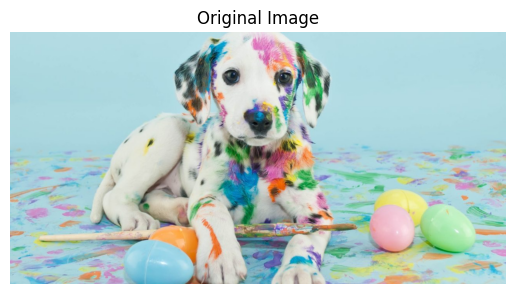

In [3]:
LeDucAnh.imshow(img)
LeDucAnh.title("Original Image")
LeDucAnh.axis('off')
LeDucAnh.show()

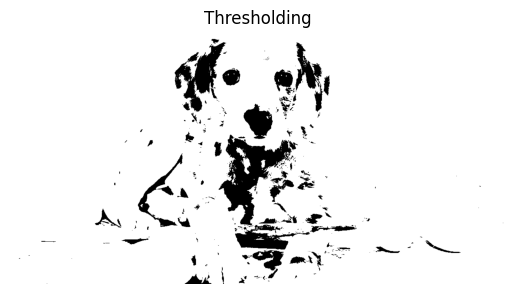

In [4]:
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

LeDucAnh.imshow(thresh, cmap='gray')
LeDucAnh.title("Thresholding")
LeDucAnh.axis('off')
LeDucAnh.show()

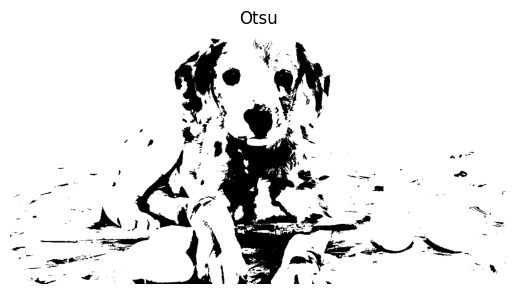

In [5]:
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

LeDucAnh.imshow(otsu, cmap='gray')
LeDucAnh.title("Otsu")
LeDucAnh.axis('off')
LeDucAnh.show()

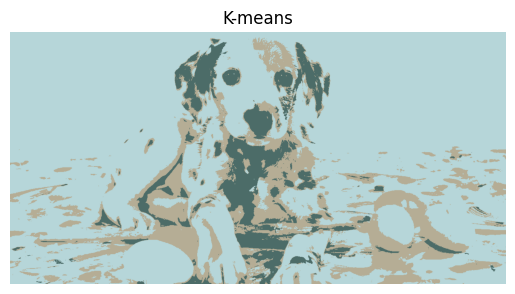

In [6]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3

_, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))

LeDucAnh.imshow(res2)
LeDucAnh.title("K-means")
LeDucAnh.axis('off')
LeDucAnh.show()

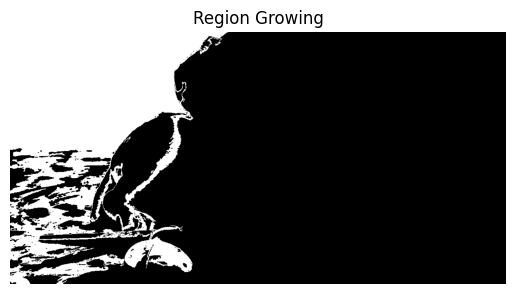

In [7]:
def region_growing(img, seed, threshold=10):
    h, w = img.shape
    visited = np.zeros((h, w), dtype=np.uint8)
    result = np.zeros((h, w), dtype=np.uint8)

    stack = [seed]
    seed_value = img[seed]

    while stack:
        x, y = stack.pop()
        if visited[x, y] == 0:
            visited[x, y] = 1
            result[x, y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(img[nx, ny]) - int(seed_value)) < threshold:
                            stack.append((nx, ny))

    return result

rg = region_growing(gray, (100,100))

LeDucAnh.imshow(rg, cmap='gray')
LeDucAnh.title("Region Growing")
LeDucAnh.axis('off')
LeDucAnh.show()

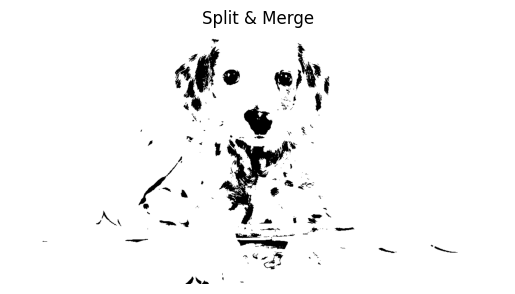

In [ ]:
_, split = cv.threshold(gray, 100, 255, cv.THRESH_BINARY)

LeDucAnh.imshow(split, cmap='gray')
LeDucAnh.title("Split & Merge")
LeDucAnh.axis('off')
LeDucAnh.show()